# Supervised Machine Learning: SVM, KNN, and Naive Bayes
A Comprehensive Hands-On Guide to Support Vector Machines, K-Nearest Neighbors, and Naive Bayes Classifiers.

---

## Overview & Educational Objectives

In this notebook, we explore three foundational families of supervised machine learning algorithms:

1. **Support Vector Machines (SVM)**: Max-margin decision boundaries, linear vs non-linear SVM, kernel tricks (RBF, Polynomial), hyperparameter tuning ($C, \gamma$), and decision boundary visualization.
2. **K-Nearest Neighbors (KNN)**: Instance-based non-parametric learning, feature scaling impact, choosing optimal $K$ via the Elbow Method, KNN Regression, and distance metrics comparison (Euclidean vs. Manhattan).
3. **Naive Bayes (NB)**: Probabilistic classification via Bayes' Theorem, Naive independence assumption, Gaussian NB for continuous features, Multinomial NB for document/text classification, Bernoulli NB for binary features, and a systematic comparison.

---

### Prerequisites & Libraries
We will use Python's standard data science toolchain: `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`.


In [1]:
# Setup imports and display configurations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn dataset & model imports
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, fetch_20newsgroups, make_moons, make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, RocCurveDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Machine Learning Models
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment successfully configured!")


Environment successfully configured!


---
# Section 1: Support Vector Machines (SVM)

## 1.1 Intuition & Mathematical Foundation

Support Vector Machines (SVM) are powerful supervised learning models used for classification and regression. The primary goal of a linear SVM is to find an optimal decision hyperplane that separates different classes while **maximizing the margin** (the distance between the hyperplane and the closest data points of any class).

### Key Concepts:
1. **Hyperplane**:
   A decision boundary defined as $w^T x + b = 0$, where $w$ is the weight vector perpendicular to the boundary and $b$ is the bias offset.
2. **Support Vectors**:
   The data points that lie closest to the decision boundary (on the marginal boundaries $w^T x + b = \pm 1$). These vectors solely define the boundary; removing other data points leaves the boundary unchanged.
3. **Margin Optimization**:
   The distance between the marginal boundaries is $\frac{2}{\|w\|}$. Maximizing this margin corresponds to minimizing $\frac{1}{2} \|w\|^2$.
4. **Soft Margin ($C$ Hyperparameter)**:
   Real-world data is seldom perfectly linearly separable. SVM allows controlled margin violations using slack variables $\xi_i \ge 0$:
   $$\min_{w, b, \xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} \xi_i$$
   - **Large $C$**: Heavy penalty for misclassification. Prefers tight margin, risks overfitting.
   - **Small $C$**: Tolerates misclassifications for a wider margin. Prefers smooth boundary, risks underfitting.

5. **Kernel Trick**:
   Maps input data from a lower-dimensional space into a higher-dimensional feature space where non-linearly separable data becomes linearly separable:
   $$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$


## 1.2 Linear SVM Classification & Decision Boundary Visualization

Let's begin with linear SVM on a 2D subset of the Iris dataset (Iris Setosa vs. Versicolor) to visualize the decision boundary, margins, and support vectors.


Number of Support Vectors: 10


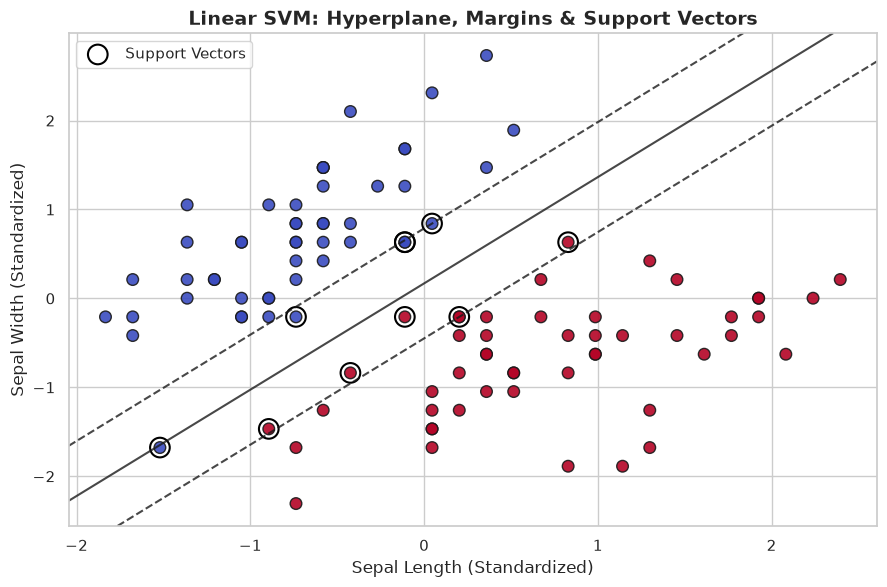

In [2]:
# Function to plot 2D SVM decision boundary, margins, and support vectors
def plot_svm_decision_boundary(model, X, y, title="SVM Decision Boundary"):
    plt.figure(figsize=(9, 6))
    
    # Scatter plot of data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=70, alpha=0.9)
    
    # Create meshgrid for decision surface
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 300)
    yy = np.linspace(ylim[0], ylim[1], 300)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Decision function values
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # Plot decision boundary (Z=0) and margins (Z=-1, Z=1)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8, linestyles=['--', '-', '--'])
    
    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200,
                   linewidth=1.5, facecolors='none', edgecolors='black', label='Support Vectors')
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Sepal Length (Standardized)")
    plt.ylabel("Sepal Width (Standardized)")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

# Load Iris dataset (binary subset: 2 features, 2 classes)
iris = load_iris()
X_iris = iris.data[:100, :2]  # First 100 samples (Setosa & Versicolor)
y_iris = iris.target[:100]

# Standardize features (CRITICAL requirement for SVM)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Fit Linear SVM
linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_iris_scaled, y_iris)

print(f"Number of Support Vectors: {len(linear_svm.support_vectors_)}")
plot_svm_decision_boundary(linear_svm, X_iris_scaled, y_iris, title="Linear SVM: Hyperplane, Margins & Support Vectors")


## 1.3 Non-Linear SVM with Kernel Tricks (RBF & Polynomial)

When data cannot be separated by a linear hyperplane, kernel functions compute inner products in a high-dimensional space without explicitly mapping points.

### Primary Kernel Functions:
1. **Polynomial Kernel**: $K(x, y) = (\gamma x^T y + r)^d$
   - Models feature interactions up to polynomial degree $d$.
2. **Radial Basis Function (RBF / Gaussian) Kernel**: $K(x, y) = \exp(-\gamma \|x - y\|^2)$
   - Infinite-dimensional implicit feature mapping based on Gaussian distance between samples.

Let's test these kernels on the non-linearly separable **Moons** dataset (`make_moons`).


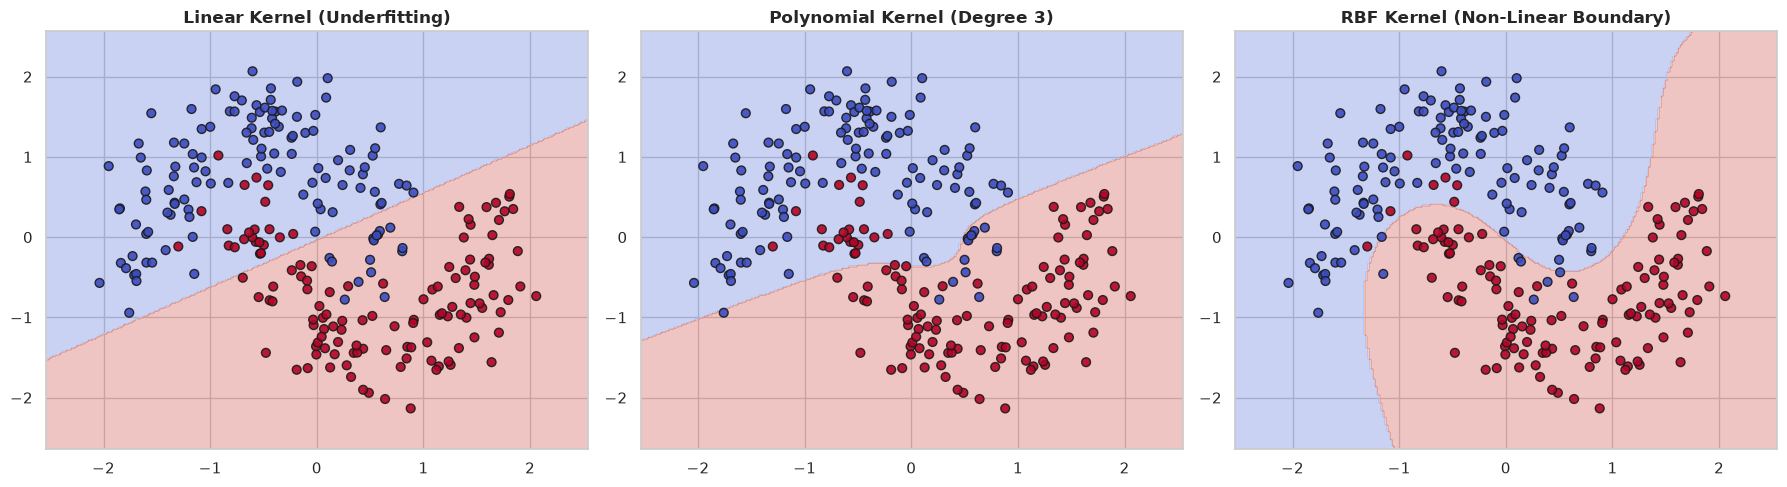

In [3]:
# Generate non-linearly separable dataset
X_moons, y_moons = make_moons(n_samples=250, noise=0.2, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# Train SVM classifiers with different kernels
svm_linear = SVC(kernel='linear', C=1.0).fit(X_moons_scaled, y_moons)
svm_poly = SVC(kernel='poly', degree=3, C=1.0).fit(X_moons_scaled, y_moons)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale').fit(X_moons_scaled, y_moons)

# Helper function to plot 2D decision contours
def plot_boundary_subplot(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40, alpha=0.9)
    ax.set_title(title, fontsize=12, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_boundary_subplot(axes[0], svm_linear, X_moons_scaled, y_moons, "Linear Kernel (Underfitting)")
plot_boundary_subplot(axes[1], svm_poly, X_moons_scaled, y_moons, "Polynomial Kernel (Degree 3)")
plot_boundary_subplot(axes[2], svm_rbf, X_moons_scaled, y_moons, "RBF Kernel (Non-Linear Boundary)")
plt.tight_layout()
plt.show()


## 1.4 SVM Hyperparameter Tuning ($C$ and $\gamma$)

For RBF kernels, two key hyperparameters govern performance:

* **$C$ (Regularization Parameter)**:
  - High $C$: Penalizes margin errors strictly $\rightarrow$ complex, flexible boundary (risk of overfitting).
  - Low $C$: Allows wider margins $\rightarrow$ smoother, simpler boundary (risk of underfitting).
* **$\gamma$ (Gamma Parameter)**:
  - High $\gamma$: Short reach of individual points $\rightarrow$ tight, localized boundaries around points (risk of overfitting).
  - Low $\gamma$: Far reach of individual points $\rightarrow$ smoother, global boundary (risk of underfitting).

Let's visualize combinations of $C$ and $\gamma$, followed by systematic tuning via `GridSearchCV`.


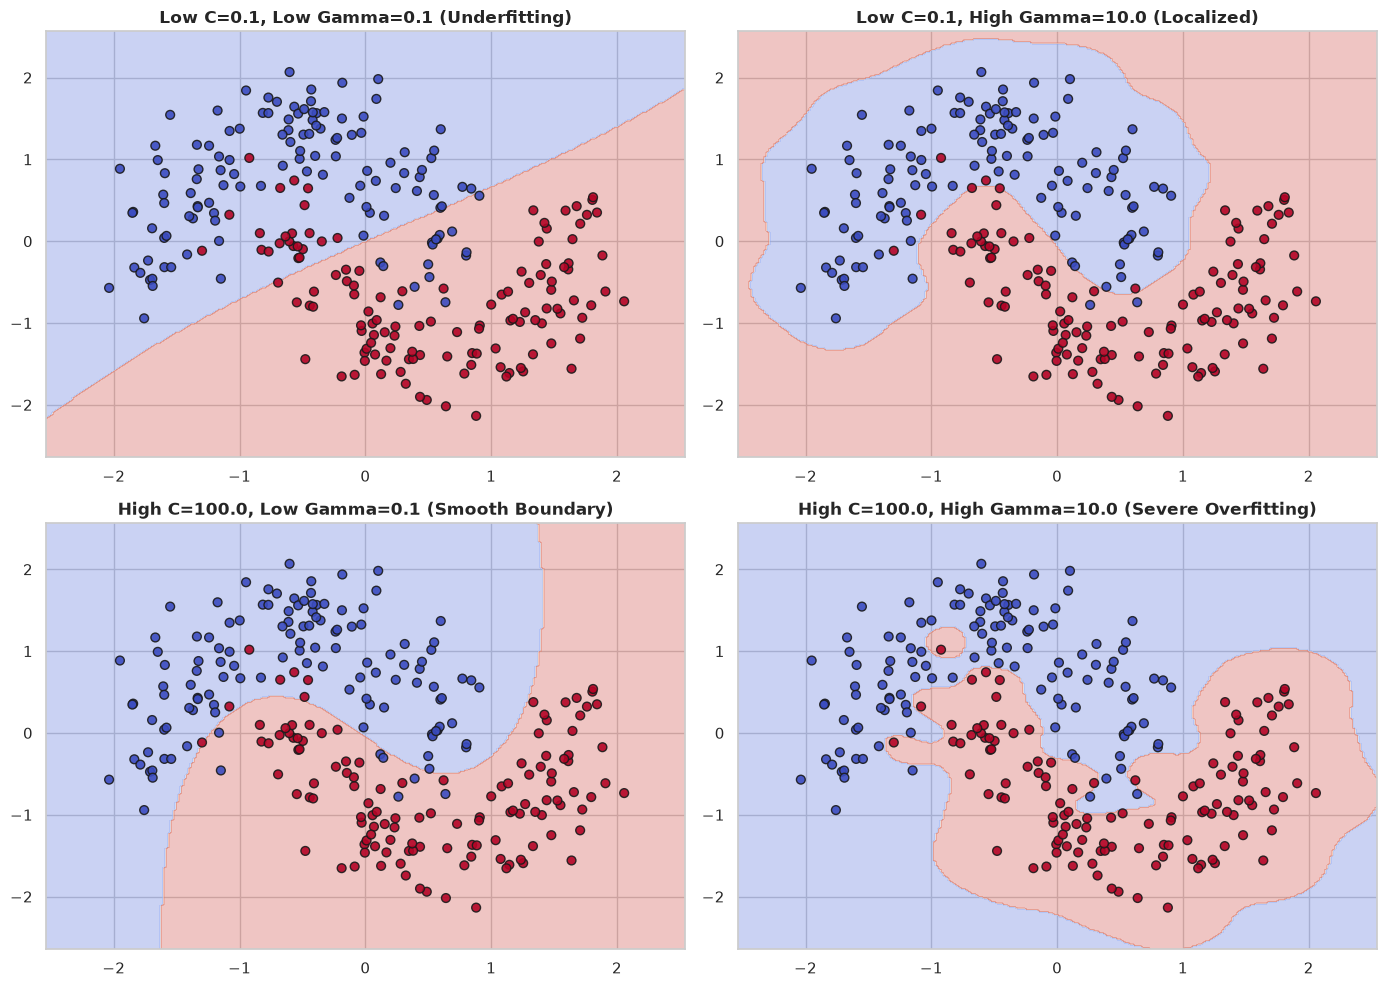

In [4]:
# Visualizing impact of varying C and gamma on RBF SVM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (0.1, 0.1, "Low C=0.1, Low Gamma=0.1 (Underfitting)"),
    (0.1, 10.0, "Low C=0.1, High Gamma=10.0 (Localized)"),
    (100.0, 0.1, "High C=100.0, Low Gamma=0.1 (Smooth Boundary)"),
    (100.0, 10.0, "High C=100.0, High Gamma=10.0 (Severe Overfitting)")
]

for ax, (C_val, gamma_val, title) in zip(axes.ravel(), configs):
    clf = SVC(kernel='rbf', C=C_val, gamma=gamma_val).fit(X_moons_scaled, y_moons)
    plot_boundary_subplot(ax, clf, X_moons_scaled, y_moons, title)

plt.tight_layout()
plt.show()


Best Hyperparameters: {'C': 1, 'gamma': 10, 'kernel': 'rbf'}
Best 5-Fold Cross-Validation Accuracy: 0.9520


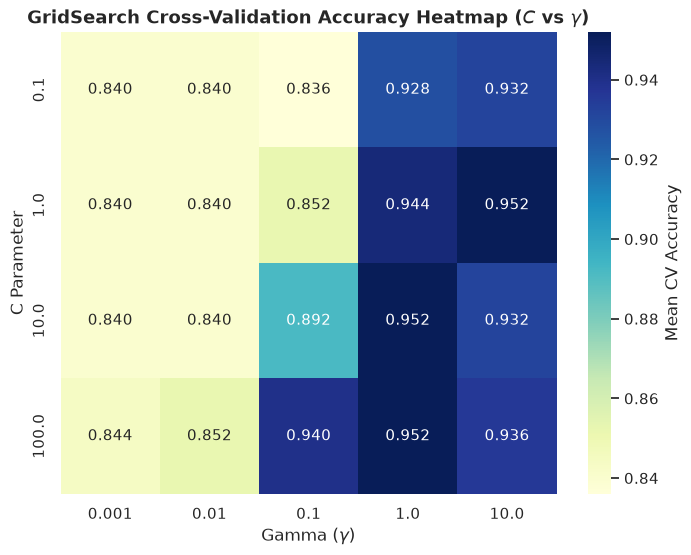

In [5]:
# Systematic Hyperparameter Tuning with GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_moons_scaled, y_moons)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best 5-Fold Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Plot Heatmap of Cross-Validation Accuracy Matrix
results = pd.DataFrame(grid_search.cv_results_)
scores_matrix = results.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Mean CV Accuracy'})
plt.title(r"GridSearch Cross-Validation Accuracy Heatmap ($C$ vs $\gamma$)", fontsize=13, fontweight='bold')
plt.xlabel(r"Gamma ($\gamma$)")
plt.ylabel("C Parameter")
plt.show()


---
# Section 2: K-Nearest Neighbors (KNN)

## 2.1 Intuition & Algorithm Overview

K-Nearest Neighbors (KNN) is an **instance-based, non-parametric, lazy learning** algorithm.

### Core Properties:
1. **Lazy Learning**: No training phase or explicit model parameters. Training samples are stored in memory, and distance calculations are performed on-the-fly during inference.
2. **Non-Parametric**: Makes no assumptions regarding underlying probability distributions.
3. **Inference Procedure**:
   - Given a query point $x_q$, compute distances to all stored training instances.
   - Identify the $K$ closest training instances.
   - **Classification**: Majority vote among $K$ neighbors.
   - **Regression**: Average (or distance-weighted average) target value among $K$ neighbors.

---

## 2.2 Feature Scaling & KNN Classification

Because KNN relies entirely on distance metrics, **feature scaling is critical**. Unscaled features with large numerical ranges will artificially dominate distance calculations.

Let's test KNN Classification on the Wine dataset (`load_wine`).


KNN Wine Classification Accuracy (K=5): 0.9444

Classification Report:


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.86      0.92        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54



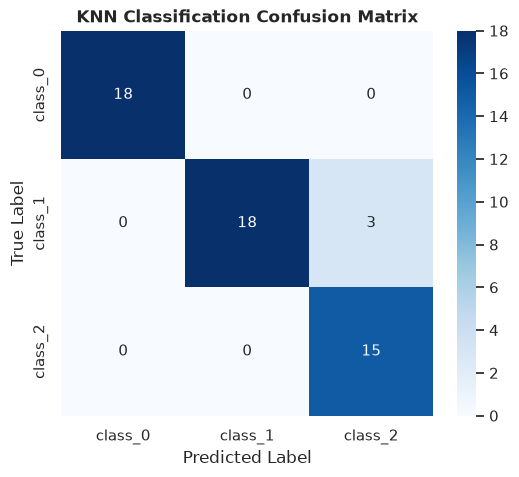

In [6]:
# Load Wine dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

# Feature Scaling (StandardScaler)
scaler_wine = StandardScaler()
X_train_w_scaled = scaler_wine.fit_transform(X_train_w)
X_test_w_scaled = scaler_wine.transform(X_test_w)

# Train KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_clf.fit(X_train_w_scaled, y_train_w)

# Evaluation
y_pred_w = knn_clf.predict(X_test_w_scaled)
acc_w = accuracy_score(y_test_w, y_pred_w)

print(f"KNN Wine Classification Accuracy (K=5): {acc_w:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_w, y_pred_w, target_names=wine.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("KNN Classification Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## 2.3 Choosing Optimal $K$: The Elbow Method & Bias-Variance Tradeoff

Selecting $K$ controls the model's capacity and generalization:

* **Small $K$ (e.g., $K=1$)**:
  - High model complexity. Sensitive to local noise and individual outliers.
  - **Low Bias, High Variance** (Overfitting).
* **Large $K$ (e.g., $K=N$)**:
  - Oversimplified boundary. Always outputs majority class.
  - **High Bias, Low Variance** (Underfitting).

We employ the **Elbow Method** by plotting training and test error rates across various values of $K$.


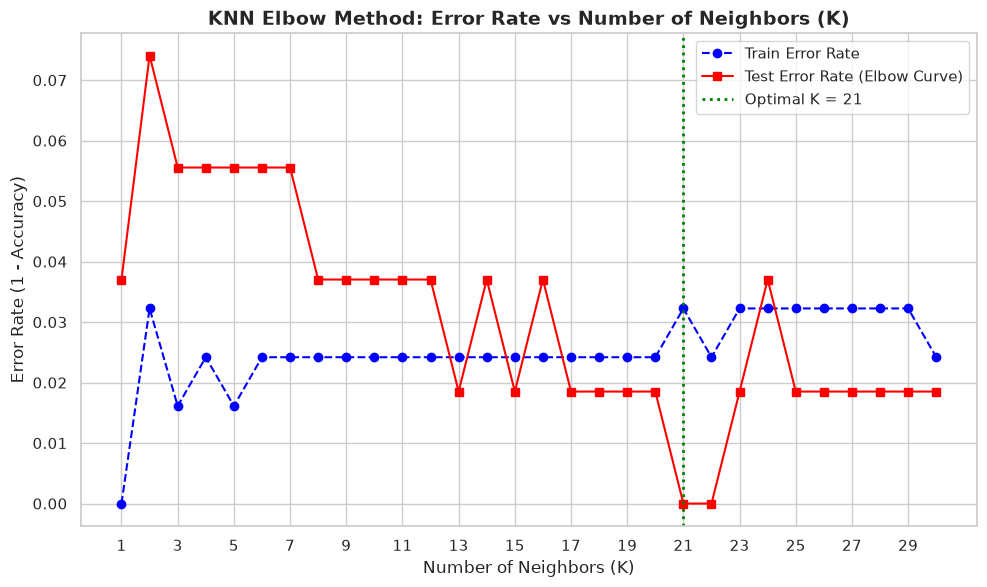

In [7]:
# Elbow Method to determine optimal K
k_range = range(1, 31)
train_errors = []
test_errors = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_w_scaled, y_train_w)
    
    train_err = 1.0 - accuracy_score(y_train_w, knn.predict(X_train_w_scaled))
    test_err = 1.0 - accuracy_score(y_test_w, knn.predict(X_test_w_scaled))
    
    train_errors.append(train_err)
    test_errors.append(test_err)

optimal_k = k_range[np.argmin(test_errors)]

# Plot Error Curves
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_errors, label='Train Error Rate', color='blue', linestyle='--', marker='o')
plt.plot(k_range, test_errors, label='Test Error Rate (Elbow Curve)', color='red', linestyle='-', marker='s')
plt.axvline(x=optimal_k, color='green', linestyle=':', linewidth=2, label=f'Optimal K = {optimal_k}')

plt.title("KNN Elbow Method: Error Rate vs Number of Neighbors (K)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.xticks(range(1, 31, 2))
plt.legend()
plt.tight_layout()
plt.show()


## 2.4 Distance Metrics: Euclidean, Manhattan, and Minkowski

The choice of distance metric determines how proximity between data points is measured.

1. **Euclidean Distance ($L_2$ norm)**:
   $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
   Straight-line distance in Euclidean space. Ideal for continuous dense features.

2. **Manhattan Distance ($L_1$ norm / Taxicab)**:
   $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$
   Sum of absolute differences along axis projections. Effective for high-dimensional or grid-like data.

3. **Minkowski Distance ($L_p$ norm)**:
   $$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$
   Generalization where $p=1$ yields Manhattan distance and $p=2$ yields Euclidean distance.


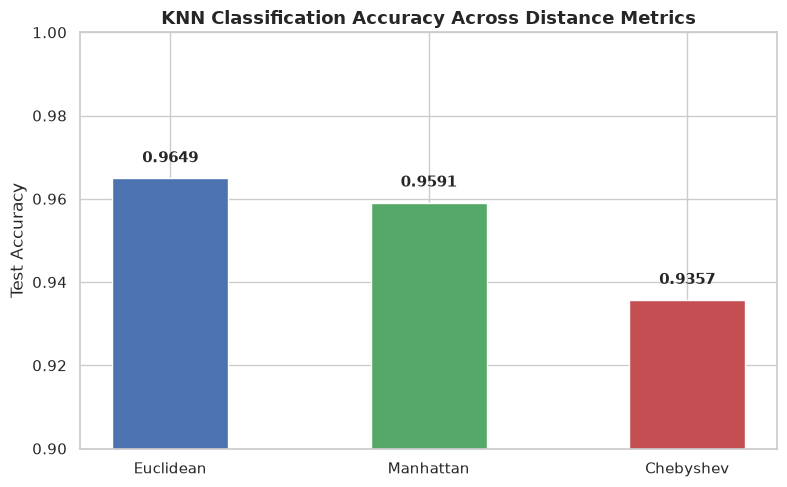

In [8]:
# Distance Metrics Comparison on Breast Cancer Dataset
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_c, y_c, test_size=0.3, random_state=42, stratify=y_c)

scaler_c = StandardScaler()
X_tr_c_scaled = scaler_c.fit_transform(X_tr_c)
X_te_c_scaled = scaler_c.transform(X_te_c)

metrics = ['euclidean', 'manhattan', 'chebyshev']
results_metric = {}

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=7, metric=m)
    knn.fit(X_tr_c_scaled, y_tr_c)
    acc = accuracy_score(y_te_c, knn.predict(X_te_c_scaled))
    results_metric[m.capitalize()] = acc

# Plot Metric Performance
plt.figure(figsize=(8, 5))
bars = plt.bar(results_metric.keys(), results_metric.values(), color=['#4c72b0', '#55a868', '#c44e52'], width=0.45)
plt.ylim(0.9, 1.0)
plt.title("KNN Classification Accuracy Across Distance Metrics", fontsize=13, fontweight='bold')
plt.ylabel("Test Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.003, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 2.5 KNN Regressor

KNN can be extended to continuous target estimation by computing target averages:
- **Uniform Weighting**: All $K$ neighbors contribute equally: $\hat{y} = \frac{1}{K} \sum_{i \in N_K(x)} y_i$
- **Distance Weighting**: Inverse-distance weighting assigns greater weight to closer neighbors: $w_i = \frac{1}{d(x, x_i)}$


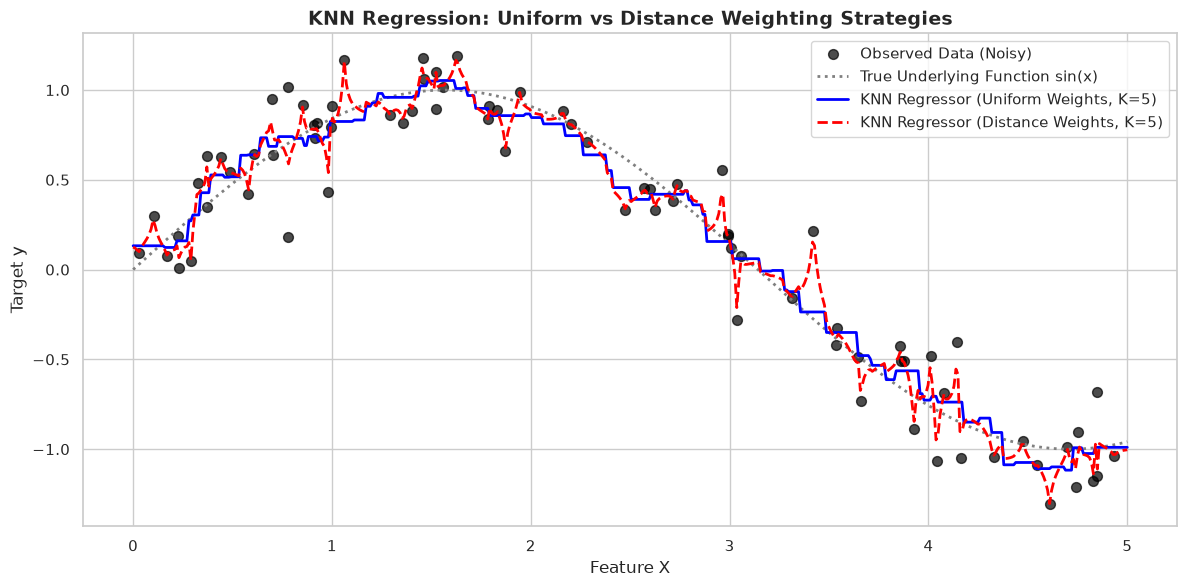

In [9]:
# Create synthetic non-linear 1D regression dataset
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, X_reg.shape[0])

# Evaluation grid
X_test_reg = np.linspace(0, 5, 500)[:, np.newaxis]

# Fit KNN Regressors
knn_reg_uniform = KNeighborsRegressor(n_neighbors=5, weights='uniform').fit(X_reg, y_reg)
knn_reg_distance = KNeighborsRegressor(n_neighbors=5, weights='distance').fit(X_reg, y_reg)

y_pred_unif = knn_reg_uniform.predict(X_test_reg)
y_pred_dist = knn_reg_distance.predict(X_test_reg)

# Visualizing regression curves
plt.figure(figsize=(12, 6))
plt.scatter(X_reg, y_reg, color='black', label='Observed Data (Noisy)', alpha=0.7, s=50)
plt.plot(X_test_reg, np.sin(X_test_reg), color='gray', linestyle=':', label='True Underlying Function sin(x)', linewidth=2)
plt.plot(X_test_reg, y_pred_unif, color='blue', label='KNN Regressor (Uniform Weights, K=5)', linewidth=2)
plt.plot(X_test_reg, y_pred_dist, color='red', linestyle='--', label='KNN Regressor (Distance Weights, K=5)', linewidth=2)

plt.title("KNN Regression: Uniform vs Distance Weighting Strategies", fontsize=14, fontweight='bold')
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()
plt.tight_layout()
plt.show()


---
# Section 3: Naive Bayes Classifiers

## 3.1 Mathematical Foundation & Bayes' Theorem

Naive Bayes classifiers are probabilistic models built upon **Bayes' Theorem**:

$$P(Y \mid X_1, X_2, \dots, X_n) = \frac{P(Y) P(X_1, X_2, \dots, X_n \mid Y)}{P(X_1, X_2, \dots, X_n)}$$

### The "Naive" Conditional Independence Assumption:
The algorithm assumes that each feature $X_i$ is **conditionally independent** of every other feature $X_j$ given the class label $Y$:

$$P(X_1, X_2, \dots, X_n \mid Y) = \prod_{i=1}^{n} P(X_i \mid Y)$$

Thus, the class posterior decision rule is:

$$\hat{Y} = \arg\max_{c} P(Y=c) \prod_{i=1}^{n} P(X_i \mid Y=c)$$

### Primary Variants:
1. **Gaussian Naive Bayes**: For continuous features assumed to follow a normal (Gaussian) distribution.
2. **Multinomial Naive Bayes**: For discrete event/word frequencies.
3. **Bernoulli Naive Bayes**: For binary feature indicators (presence/absence).


## 3.2 Gaussian Naive Bayes (Continuous Features)

In Gaussian Naive Bayes, the class-conditional probability distribution of continuous feature $X_i$ is modeled as:

$$P(X_i \mid Y = c) = \frac{1}{\sqrt{2\pi \sigma_{c,i}^2}} \exp \left( -\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2} \right)$$

where $\mu_{c,i}$ and $\sigma_{c,i}^2$ are the mean and variance of feature $X_i$ within class $c$.


Gaussian Naive Bayes Accuracy: 0.9357

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.89      0.91        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



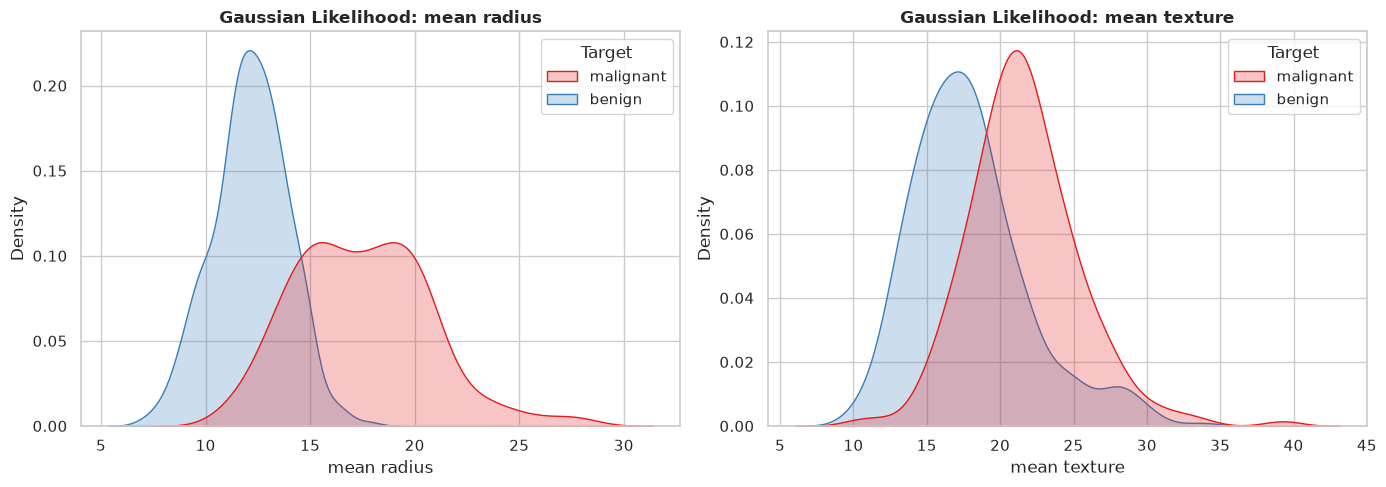

In [10]:
# Fit Gaussian Naive Bayes on Breast Cancer dataset
gnb = GaussianNB()
gnb.fit(X_tr_c_scaled, y_tr_c)

y_pred_gnb = gnb.predict(X_te_c_scaled)
gnb_acc = accuracy_score(y_te_c, y_pred_gnb)

print(f"Gaussian Naive Bayes Accuracy: {gnb_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_te_c, y_pred_gnb, target_names=cancer.target_names))

# Visualize Feature Probability Density Distributions
df_cancer = pd.DataFrame(X_c[:, :2], columns=cancer.feature_names[:2])
df_cancer['Target'] = [cancer.target_names[i] for i in y_c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=df_cancer, x=cancer.feature_names[0], hue='Target', fill=True, common_norm=False, ax=axes[0], palette='Set1')
axes[0].set_title(f"Gaussian Likelihood: {cancer.feature_names[0]}", fontweight='bold')

sns.kdeplot(data=df_cancer, x=cancer.feature_names[1], hue='Target', fill=True, common_norm=False, ax=axes[1], palette='Set1')
axes[1].set_title(f"Gaussian Likelihood: {cancer.feature_names[1]}", fontweight='bold')

plt.tight_layout()
plt.show()


## 3.3 Multinomial Naive Bayes (Text Classification Example)

Multinomial Naive Bayes models feature counts (e.g., word occurrences in document classification).

### Laplace Additive Smoothing ($lpha$):
To avoid zero-probability estimates for unseen words during inference, Laplace smoothing adds $\alpha > 0$:
$$P(x_i \mid Y = c) = \frac{N_{c,i} + \alpha}{N_c + \alpha \cdot n}$$
where $N_{c,i}$ is the count of term $i$ in class $c$, $N_c$ is total term count in class $c$, and $n$ is vocabulary size.


In [11]:
# Text Classification example on 20 Newsgroups subset
categories = ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.religion.misc']

newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

# Vectorize raw text into word count matrix (Bag of Words)
vectorizer = CountVectorizer(stop_words='english', max_features=2500)
X_train_vec = vectorizer.fit_transform(newsgroups_train.data)
X_test_vec = vectorizer.transform(newsgroups_test.data)

# Train Multinomial Naive Bayes
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train_vec, newsgroups_train.target)

y_pred_mnb = mnb.predict(X_test_vec)
mnb_acc = accuracy_score(newsgroups_test.target, y_pred_mnb)

print(f"Multinomial Naive Bayes Test Accuracy: {mnb_acc:.4f}\n")

# Predicting new sample texts
sample_texts = [
    "NASA launched a new rocket telescope to explore deep space galaxies.",
    "Computer graphics cards render 3D pixels and complex geometric shaders.",
    "Theological debates discuss morality, divine existence, and spiritual principles."
]

sample_vec = vectorizer.transform(sample_texts)
predictions = mnb.predict(sample_vec)

print("--- Sample Predictions ---")
for text, pred in zip(sample_texts, predictions):
    print(f"Text: '{text}'")
    print(f"Predicted Category: {categories[pred]}\n")


Multinomial Naive Bayes Test Accuracy: 0.7458

--- Sample Predictions ---
Text: 'NASA launched a new rocket telescope to explore deep space galaxies.'
Predicted Category: sci.space

Text: 'Computer graphics cards render 3D pixels and complex geometric shaders.'
Predicted Category: comp.graphics

Text: 'Theological debates discuss morality, divine existence, and spiritual principles.'
Predicted Category: talk.religion.misc



## 3.4 Bernoulli Naive Bayes

Bernoulli Naive Bayes explicitly models **binary feature indicators** ($x_i \in \{0, 1\}$ reflecting feature presence or absence):

$$P(X_i \mid Y = c) = P(i \mid c)^{x_i} \cdot (1 - P(i \mid c))^{(1 - x_i)}$$

Unlike Multinomial NB which focuses on word counts, Bernoulli NB explicitly penalizes the absence of key words.


In [12]:
# Convert count matrix to binary indicators (0 or 1)
X_train_bin = (X_train_vec > 0).astype(int)
X_test_bin = (X_test_vec > 0).astype(int)

# Train Bernoulli Naive Bayes
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_train_bin, newsgroups_train.target)

y_pred_bnb = bnb.predict(X_test_bin)
bnb_acc = accuracy_score(newsgroups_test.target, y_pred_bnb)

print(f"Bernoulli Naive Bayes Accuracy: {bnb_acc:.4f}")


Bernoulli Naive Bayes Accuracy: 0.6452


## 3.5 Systematic Comparison of Naive Bayes Variants

| Naive Bayes Variant | Feature Input Type | Underlying Distribution | Ideal Use Case |
| :--- | :--- | :--- | :--- |
| **Gaussian NB** | Continuous real numbers | Gaussian (Normal) Distribution | Physical dimensions, sensor measurements, medical records |
| **Multinomial NB** | Non-negative integer counts / term frequencies | Multinomial Distribution | Text/document classification (Word counts, TF-IDF) |
| **Bernoulli NB** | Binary indicators (0 or 1) | Bernoulli Distribution | Short document processing, spam filtering (Presence/Absence) |


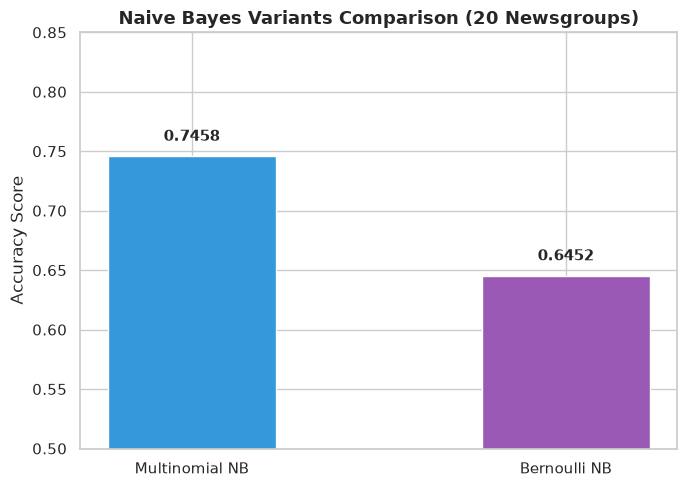

In [13]:
# Compare Naive Bayes Variants on Text Dataset
nb_comparison = pd.DataFrame({
    'Variant': ['Multinomial NB', 'Bernoulli NB'],
    'Accuracy': [mnb_acc, bnb_acc]
})

plt.figure(figsize=(7, 5))
bars = plt.bar(nb_comparison['Variant'], nb_comparison['Accuracy'], color=['#3498db', '#9b59b6'], width=0.45)
plt.ylim(0.5, 0.85)
plt.title("Naive Bayes Variants Comparison (20 Newsgroups)", fontsize=13, fontweight='bold')
plt.ylabel("Accuracy Score")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


---
# Section 4: Comprehensive Algorithm Comparison & Decision Framework

Below is a comparative matrix highlighting the practical characteristics of **SVM**, **KNN**, and **Naive Bayes**:

| Characteristic | Support Vector Machines (SVM) | K-Nearest Neighbors (KNN) | Naive Bayes (NB) |
| :--- | :--- | :--- | :--- |
| **Training Speed** | Slow ($O(N^2 \cdot d)$ to $O(N^3 \cdot d)$) | Instant $O(1)$ (No explicit training) | Very Fast $O(N \cdot d)$ |
| **Inference Speed** | Fast ($O(N_{sv} \cdot d)$) | Slow ($O(N \cdot d)$ per query) | Extremely Fast $O(C \cdot d)$ |
| **Feature Scaling Required?** | **Yes** (Essential) | **Yes** (Essential) | **No** (Scale invariant) |
| **High Dimensionality?** | Handles high dimensions well | Poor performance (Curse of Dimensionality) | Handles high dimensions exceptionally well |
| **Interpretability** | Low (Black box in kernel space) | High (Direct neighbor examination) | High (Explicit probabilities & likelihoods) |
| **Key Hyperparameters** | $C$, Kernel, $\gamma$, degree | $K$, Distance metric ($L_1, L_2$), Weighting | Smoothing factor $\alpha$, Variant selection |

---
## Summary Guidelines: When to Use Which?

1. **Choose Support Vector Machines (SVM)** when:
   - Data has complex, non-linear boundaries requiring kernel projections.
   - Dataset size is small to medium ($N < 100,000$).
   - High classification accuracy is prioritized over training speed or interpretability.

2. **Choose K-Nearest Neighbors (KNN)** when:
   - You require a simple baseline model with zero training computation.
   - Prediction depends on local pattern similarity.
   - Feature count is small ($d < 20$) and dataset size is manageable.

3. **Choose Naive Bayes** when:
   - You are dealing with text processing, NLP, or high-dimensional count data.
   - Real-time training or lightning-fast streaming predictions are required.
   - Computational resources and memory are constrained.
